In [ ]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv('eth-ndvi-subnat-full.csv')

# Show basic information
print("=" * 50)
print("DATASET BASIC INFORMATION")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(df.columns.tolist())

print("\n" + "=" * 50)
print("FIRST FEW ROWS")
print("=" * 50)
print(df.head(10))

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("ADDITIONAL INFO")
print("=" * 50)
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique administrative levels: {df['adm_level'].unique()}")
print(f"Unique administrative IDs: {df['adm_id'].nunique()}")
print(f"Unique PCODEs: {df['PCODE'].nunique()}")


DATASET BASIC INFORMATION

Shape: (76895, 8)
Rows: 76,895
Columns: 8

COLUMN NAMES
['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'vim', 'vim_avg', 'viq']

FIRST FEW ROWS
         date  adm_level  adm_id PCODE  n_pixels       vim   vim_avg  \
0  2002-07-01          1  900532  ET14      20.0  0.472980  0.448331   
1  2002-07-11          1  900532  ET14      20.0  0.498520  0.472437   
2  2002-07-21          1  900532  ET14      20.0  0.530495  0.497552   
3  2002-08-01          1  900532  ET14      20.0  0.563190  0.522598   
4  2002-08-11          1  900532  ET14      20.0  0.593230  0.544917   
5  2002-08-21          1  900532  ET14      20.0  0.620080  0.564503   
6  2002-09-01          1  900532  ET14      20.0  0.637930  0.577719   
7  2002-09-11          1  900532  ET14      20.0  0.641700  0.581860   
8  2002-09-21          1  900532  ET14      20.0  0.630110  0.576386   
9  2002-10-01          1  900532  ET14      20.0  0.603845  0.561525   

          viq  
0  104.946396 

DETAILED MISSING VALUES ANALYSIS
✓ No missing values found in the dataset!

Selected region: ET1401 (adm_id: 1007457)
Number of data points: 5070
Date range: 2002-07-01 00:00:00 to 2025-12-11 00:00:00


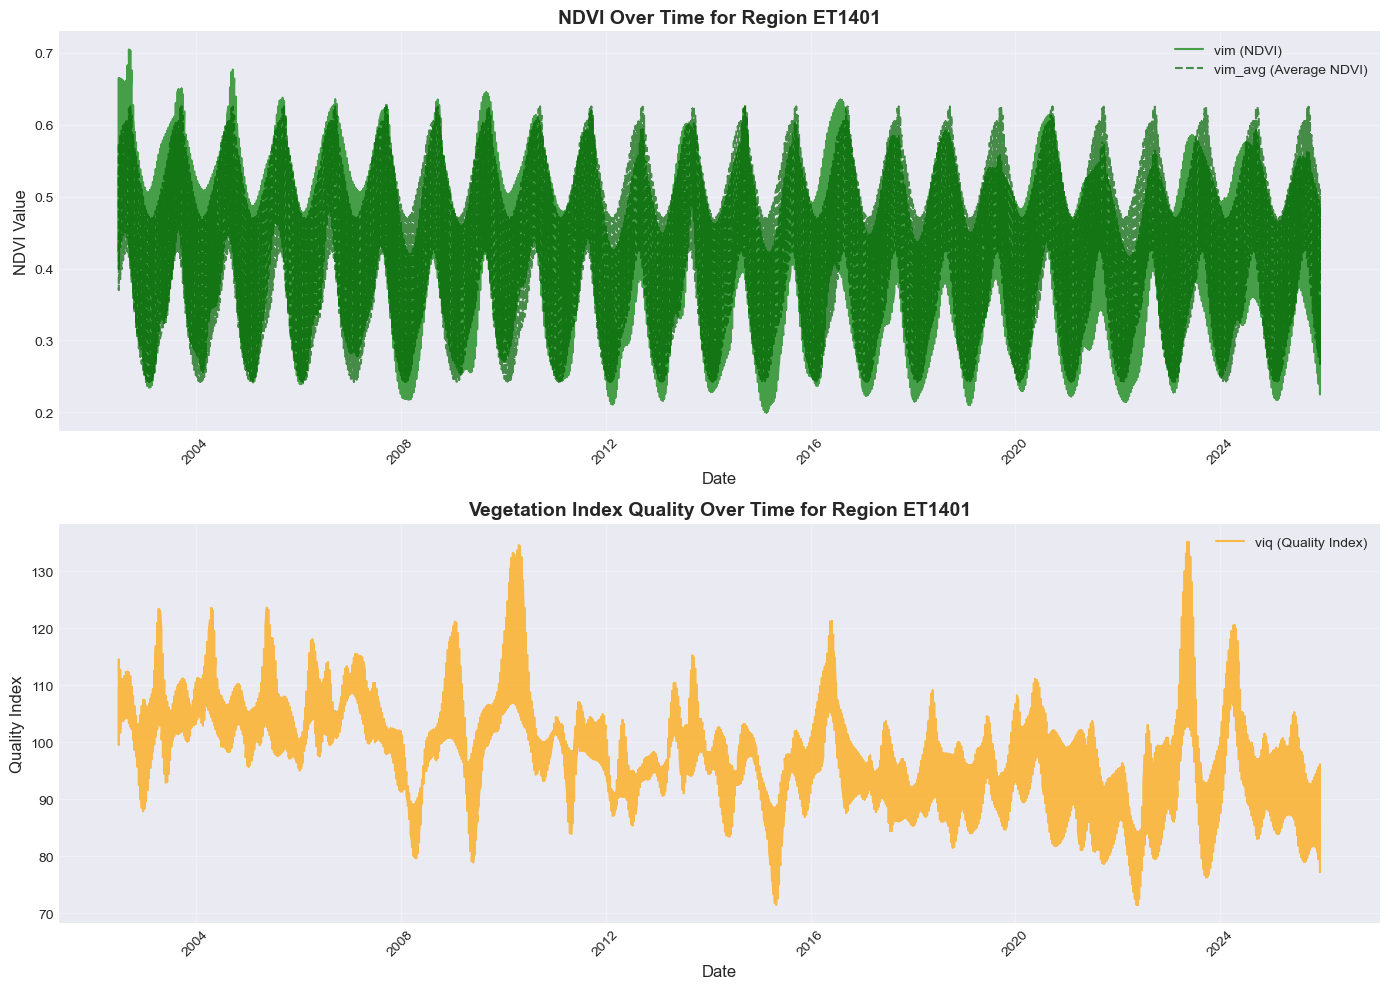


SUMMARY STATISTICS FOR REGION ET1401
               vim      vim_avg          viq
count  5070.000000  5070.000000  5070.000000
mean      0.414334     0.423204    98.233021
std       0.109133     0.106371     8.597392
min       0.199900     0.242750    71.465510
25%       0.323025     0.332292    92.744575
50%       0.417719     0.420631    97.887675
75%       0.500047     0.509888   103.400113
max       0.704400     0.624945   135.086580


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')
sns.set_palette("husl")

# Detailed missing values check
print("=" * 50)
print("DETAILED MISSING VALUES ANALYSIS")
print("=" * 50)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✓ No missing values found in the dataset!")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Select one region for plotting (using the first region with most data points)
# Let's use a region that appears frequently
region_counts = df['PCODE'].value_counts()
selected_pcode = region_counts.index[0]
selected_region_data = df[df['PCODE'] == selected_pcode].copy()
selected_region_data = selected_region_data.sort_values('date')

print(f"\nSelected region: {selected_pcode} (adm_id: {selected_region_data['adm_id'].iloc[0]})")
print(f"Number of data points: {len(selected_region_data)}")
print(f"Date range: {selected_region_data['date'].min()} to {selected_region_data['date'].max()}")

# Plot NDVI over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: vim (NDVI) over time
axes[0].plot(selected_region_data['date'], selected_region_data['vim'], 
             linewidth=1.5, alpha=0.7, label='vim (NDVI)', color='green')
axes[0].plot(selected_region_data['date'], selected_region_data['vim_avg'], 
             linewidth=1.5, alpha=0.7, label='vim_avg (Average NDVI)', color='darkgreen', linestyle='--')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('NDVI Value', fontsize=12)
axes[0].set_title(f'NDVI Over Time for Region {selected_pcode}', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: viq (Vegetation Index Quality) over time
axes[1].plot(selected_region_data['date'], selected_region_data['viq'], 
             linewidth=1.5, alpha=0.7, label='viq (Quality Index)', color='orange')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Quality Index', fontsize=12)
axes[1].set_title(f'Vegetation Index Quality Over Time for Region {selected_pcode}', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics for the selected region
print("\n" + "=" * 50)
print(f"SUMMARY STATISTICS FOR REGION {selected_pcode}")
print("=" * 50)
print(selected_region_data[['vim', 'vim_avg', 'viq']].describe())


In [3]:
# Check temporal gaps per region
print("=" * 50)
print("TEMPORAL GAPS ANALYSIS PER REGION")
print("=" * 50)

# Ensure date is datetime (already converted in previous cell)
# df['date'] = pd.to_datetime(df['date'])

# Calculate expected date frequency (10-day intervals)
# Generate expected dates for the full date range
full_date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='10D')
expected_dates_count = len(full_date_range)

print(f"\nExpected date range: {df['date'].min()} to {df['date'].max()}")
print(f"Expected number of 10-day intervals: {expected_dates_count}")

# Analyze gaps per region (using PCODE as region identifier)
gap_analysis = []

for pcode in df['PCODE'].unique():
    region_data = df[df['PCODE'] == pcode].copy()
    region_data = region_data.sort_values('date')
    
    # Get actual dates for this region
    actual_dates = set(region_data['date'].dt.date)
    
    # Get expected dates for this region's date range
    region_start = region_data['date'].min()
    region_end = region_data['date'].max()
    expected_dates = pd.date_range(start=region_start, end=region_end, freq='10D')
    expected_dates_set = set(expected_dates.date)
    
    # Find missing dates
    missing_dates = expected_dates_set - actual_dates
    missing_count = len(missing_dates)
    
    # Calculate gap statistics
    date_diffs = region_data['date'].diff().dt.days
    date_diffs = date_diffs[date_diffs > 0]  # Remove first NaN and negative values
    
    # Count gaps (intervals > 10 days)
    gaps = date_diffs[date_diffs > 10]
    gap_count = len(gaps)
    max_gap = date_diffs.max() if len(date_diffs) > 0 else 0
    
    gap_analysis.append({
        'PCODE': pcode,
        'adm_id': region_data['adm_id'].iloc[0],
        'adm_level': region_data['adm_level'].iloc[0],
        'start_date': region_start,
        'end_date': region_end,
        'expected_observations': len(expected_dates),
        'actual_observations': len(region_data),
        'missing_count': missing_count,
        'gap_count': gap_count,
        'max_gap_days': max_gap,
        'coverage_pct': (len(region_data) / len(expected_dates) * 100) if len(expected_dates) > 0 else 0
    })

gap_df = pd.DataFrame(gap_analysis)

# Sort by missing count (descending) to see regions with most gaps
gap_df = gap_df.sort_values('missing_count', ascending=False)

print(f"\nTotal regions analyzed: {len(gap_df)}")
print(f"\nRegions with temporal gaps: {len(gap_df[gap_df['missing_count'] > 0])}")
print(f"Regions with no gaps: {len(gap_df[gap_df['missing_count'] == 0])}")

print("\n" + "=" * 50)
print("TOP 10 REGIONS WITH MOST TEMPORAL GAPS")
print("=" * 50)
print(gap_df[['PCODE', 'adm_id', 'start_date', 'end_date', 'expected_observations', 
              'actual_observations', 'missing_count', 'gap_count', 'max_gap_days', 
              'coverage_pct']].head(10).to_string(index=False))

print("\n" + "=" * 50)
print("GAP STATISTICS SUMMARY")
print("=" * 50)
print(f"Average missing observations per region: {gap_df['missing_count'].mean():.2f}")
print(f"Median missing observations per region: {gap_df['missing_count'].median():.2f}")
print(f"Max missing observations in a region: {gap_df['missing_count'].max()}")
print(f"\nAverage coverage percentage: {gap_df['coverage_pct'].mean():.2f}%")
print(f"Median coverage percentage: {gap_df['coverage_pct'].median():.2f}%")
print(f"Min coverage percentage: {gap_df['coverage_pct'].min():.2f}%")

print("\n" + "=" * 50)
print("REGIONS WITH MAXIMUM GAP DAYS")
print("=" * 50)
max_gap_regions = gap_df.nlargest(10, 'max_gap_days')
print(max_gap_regions[['PCODE', 'adm_id', 'max_gap_days', 'start_date', 'end_date']].to_string(index=False))


TEMPORAL GAPS ANALYSIS PER REGION

Expected date range: 2002-07-01 00:00:00 to 2025-12-11 00:00:00
Expected number of 10-day intervals: 857

Total regions analyzed: 85

Regions with temporal gaps: 85
Regions with no gaps: 0

TOP 10 REGIONS WITH MOST TEMPORAL GAPS
 PCODE  adm_id start_date   end_date  expected_observations  actual_observations  missing_count  gap_count  max_gap_days  coverage_pct
  ET14  900532 2002-07-01 2025-12-11                    857                  845            770        164          11.0     98.599767
ET0504 1007505 2002-07-01 2025-12-11                    857                  845            770        164          11.0     98.599767
ET0406 1007513 2002-07-01 2025-12-11                    857                  845            770        164          11.0     98.599767
ET0403 1007512 2002-07-01 2025-12-11                    857                  845            770        164          11.0     98.599767
ET0401 1007511 2002-07-01 2025-12-11                    857  

NDVI COMPARISON ACROSS MULTIPLE REGIONS

Selected regions for comparison:
1. ET1401 (adm_id: 1007457) - 5070 observations
2. ET0307 (adm_id: 1007490) - 1690 observations
3. ET0504 (adm_id: 1007505) - 845 observations


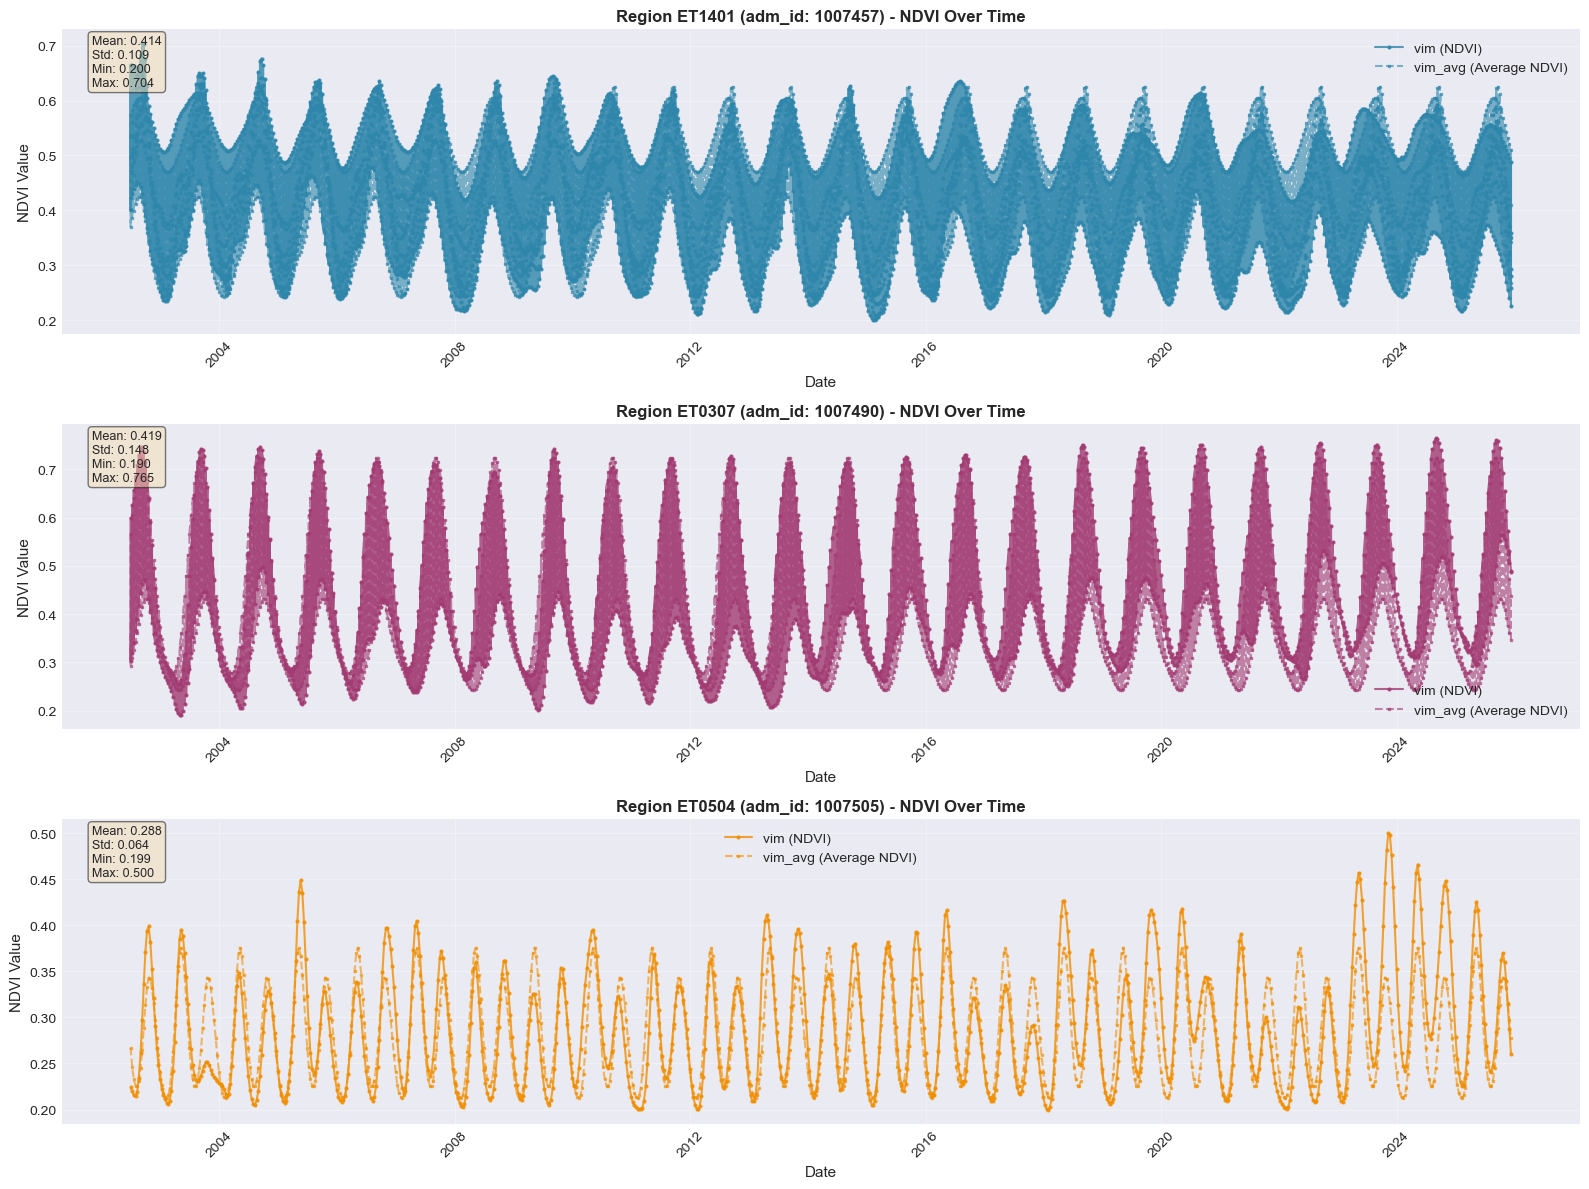


COMBINED COMPARISON PLOT


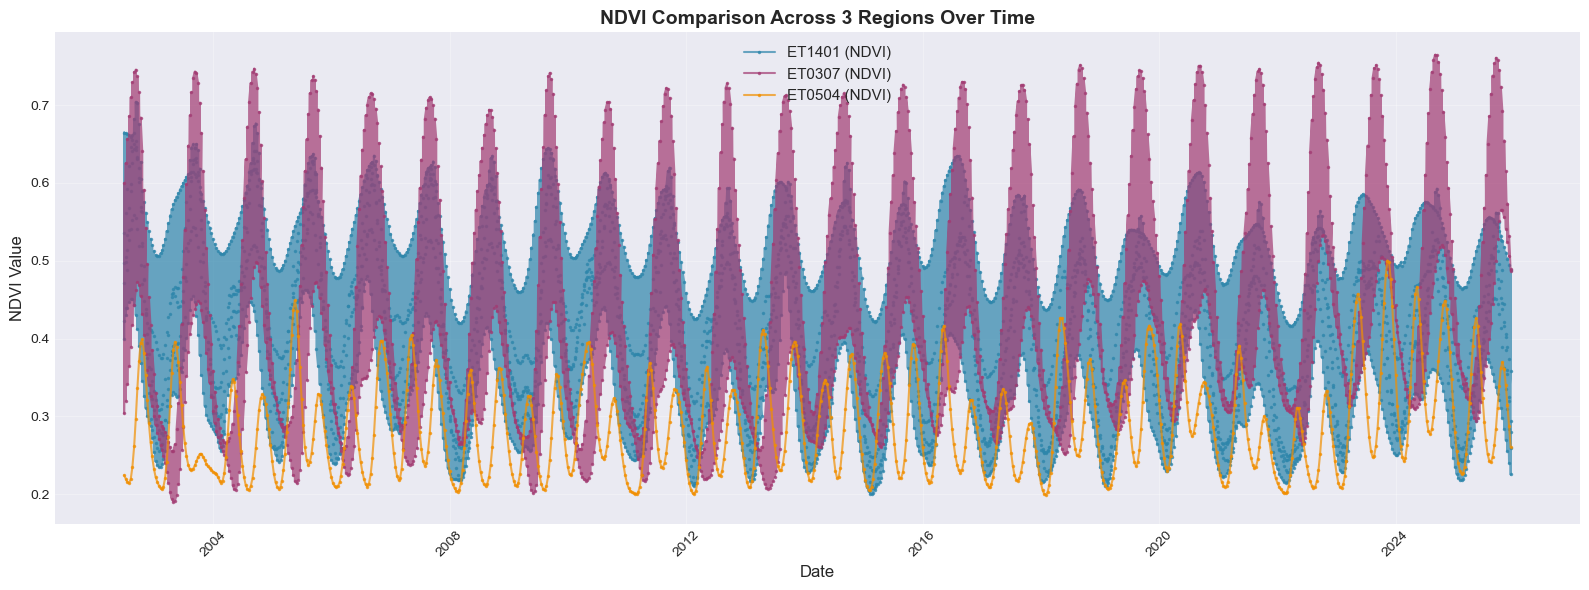


SUMMARY STATISTICS COMPARISON
 PCODE  adm_id  Mean NDVI  Std NDVI  Min NDVI  Max NDVI  Observations
ET1401 1007457   0.414334  0.109133  0.199900  0.704400          5070
ET0307 1007490   0.418578  0.147891  0.190067  0.764859          1690
ET0504 1007505   0.288231  0.063730  0.199130  0.500191           845


In [ ]:
# Plot NDVI vs time for 2-3 regions
print("=" * 50)
print("NDVI COMPARISON ACROSS MULTIPLE REGIONS")
print("=" * 50)

# Select 3 regions with good data coverage
# Get regions with most observations
region_counts = df['PCODE'].value_counts()
top_regions = region_counts.head(3).index.tolist()

print(f"\nSelected regions for comparison:")
for i, pcode in enumerate(top_regions, 1):
    region_data = df[df['PCODE'] == pcode]
    print(f"{i}. {pcode} (adm_id: {region_data['adm_id'].iloc[0]}) - {len(region_data)} observations")

# Create the plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Different colors for each region

for idx, pcode in enumerate(top_regions):
    region_data = df[df['PCODE'] == pcode].copy()
    region_data = region_data.sort_values('date')
    
    # Plot vim (NDVI) over time
    axes[idx].plot(region_data['date'], region_data['vim'], 
                   linewidth=1.5, alpha=0.8, label='vim (NDVI)', 
                   color=colors[idx], marker='o', markersize=2)
    axes[idx].plot(region_data['date'], region_data['vim_avg'], 
                   linewidth=1.5, alpha=0.6, label='vim_avg (Average NDVI)', 
                   color=colors[idx], linestyle='--', marker='s', markersize=1.5)
    
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('NDVI Value', fontsize=11)
    axes[idx].set_title(f'Region {pcode} (adm_id: {region_data["adm_id"].iloc[0]}) - NDVI Over Time', 
                        fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add statistics text box
    mean_ndvi = region_data['vim'].mean()
    std_ndvi = region_data['vim'].std()
    min_ndvi = region_data['vim'].min()
    max_ndvi = region_data['vim'].max()
    
    stats_text = f'Mean: {mean_ndvi:.3f}\nStd: {std_ndvi:.3f}\nMin: {min_ndvi:.3f}\nMax: {max_ndvi:.3f}'
    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Create a combined comparison plot
print("\n" + "=" * 50)
print("COMBINED COMPARISON PLOT")
print("=" * 50)

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

for idx, pcode in enumerate(top_regions):
    region_data = df[df['PCODE'] == pcode].copy()
    region_data = region_data.sort_values('date')
    
    ax.plot(region_data['date'], region_data['vim'], 
            linewidth=1.5, alpha=0.7, label=f'{pcode} (NDVI)', 
            color=colors[idx], marker='o', markersize=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('NDVI Value', fontsize=12)
ax.set_title('NDVI Comparison Across 3 Regions Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics for comparison
print("\n" + "=" * 50)
print("SUMMARY STATISTICS COMPARISON")
print("=" * 50)
comparison_stats = []
for pcode in top_regions:
    region_data = df[df['PCODE'] == pcode]
    comparison_stats.append({
        'PCODE': pcode,
        'adm_id': region_data['adm_id'].iloc[0],
        'Mean NDVI': region_data['vim'].mean(),
        'Std NDVI': region_data['vim'].std(),
        'Min NDVI': region_data['vim'].min(),
        'Max NDVI': region_data['vim'].max(),
        'Observations': len(region_data)
    })

comparison_df = pd.DataFrame(comparison_stats)
print(comparison_df.to_string(index=False))


SEASONALITY ANALYSIS

Date range: 2002-07-01 00:00:00 to 2025-12-11 00:00:00
Years covered: 2002 to 2025
Total dekads in a year: 36 (12 months × 3 dekads)

MONTHLY SEASONALITY
      mean    std    min    max  count
Jan  0.372  0.143  0.099  0.819   6279
Feb  0.336  0.129  0.097  0.809   6279
Mar  0.345  0.137  0.096  0.816   6279
Apr  0.407  0.167  0.096  0.830   6279
May  0.470  0.190  0.093  0.868   6279
Jun  0.494  0.206  0.084  0.869   6279
Jul  0.524  0.209  0.085  0.875   6552
Aug  0.571  0.203  0.091  0.884   6552
Sep  0.586  0.197  0.099  0.882   6552
Oct  0.561  0.187  0.107  0.876   6552
Nov  0.505  0.178  0.107  0.869   6552
Dec  0.438  0.164  0.103  0.852   6461

DEKAD SEASONALITY (Top 10 and Bottom 10 dekads by mean NDVI)

Top 10 dekads (highest NDVI):
                mean    std  count
dekad_of_year                     
25             0.588  0.199   2184
26             0.588  0.197   2184
24             0.583  0.201   2184
27             0.583  0.194   2184
28            

C:\Users\sewasew tadele\AppData\Local\Temp\ipykernel_26112\869801155.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(month_data, labels=month_order, patch_artist=True)


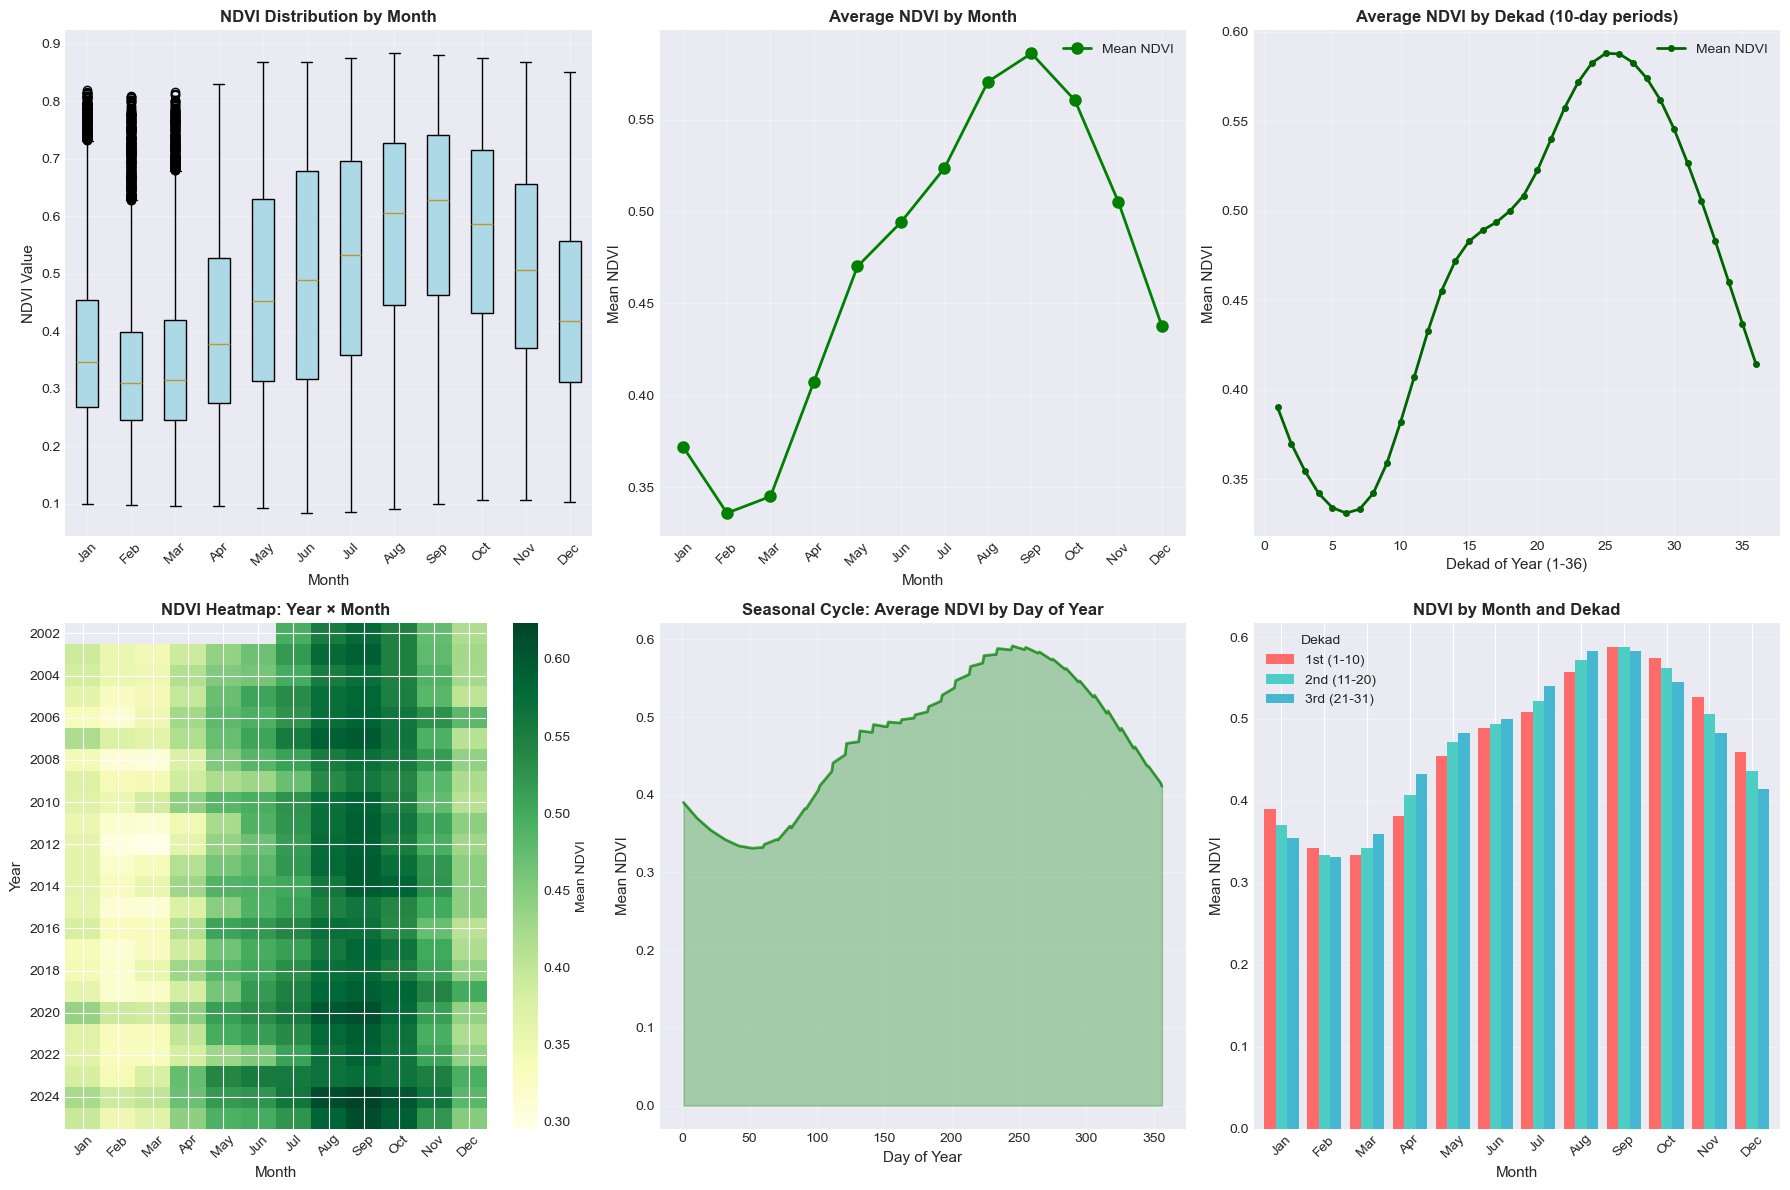


SEASONAL STATISTICS
Month with highest average NDVI: Sep (0.586)
Month with lowest average NDVI: Feb (0.336)
Range (max - min monthly average): 0.250

Dekad with highest average NDVI: 25 (0.588)
Dekad with lowest average NDVI: 6 (0.331)
Range (max - min dekad average): 0.257


In [ ]:
# Analyze seasonality (month and dekad)
print("=" * 50)
print("SEASONALITY ANALYSIS")
print("=" * 50)

# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

# Calculate dekad (10-day period within month: 1-3)
df['day_of_month'] = df['date'].dt.day
df['dekad'] = df['day_of_month'].apply(lambda x: 1 if x <= 10 else (2 if x <= 20 else 3))
df['month_dekad'] = df['month'].astype(str) + '-' + df['dekad'].astype(str)

# Calculate dekad of year (1-36, since 12 months * 3 dekads = 36)
df['dekad_of_year'] = (df['month'] - 1) * 3 + df['dekad']

print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Years covered: {df['year'].min()} to {df['year'].max()}")
print(f"Total dekads in a year: 36 (12 months × 3 dekads)")

# Monthly seasonality analysis
print("\n" + "=" * 50)
print("MONTHLY SEASONALITY")
print("=" * 50)
monthly_stats = df.groupby('month')['vim'].agg(['mean', 'std', 'min', 'max', 'count']).round(3)
monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print(monthly_stats)

# Dekad seasonality analysis
print("\n" + "=" * 50)
print("DEKAD SEASONALITY (Top 10 and Bottom 10 dekads by mean NDVI)")
print("=" * 50)
dekad_stats = df.groupby('dekad_of_year')['vim'].agg(['mean', 'std', 'count']).round(3)
dekad_stats = dekad_stats.sort_values('mean', ascending=False)
print("\nTop 10 dekads (highest NDVI):")
print(dekad_stats.head(10))
print("\nBottom 10 dekads (lowest NDVI):")
print(dekad_stats.tail(10))

# Create visualizations
fig = plt.figure(figsize=(18, 12))

# 1. Monthly box plot
ax1 = plt.subplot(2, 3, 1)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month_name'] = df['date'].dt.strftime('%b')
month_data = [df[df['month_name'] == month]['vim'].values for month in month_order]
bp1 = ax1.boxplot(month_data, labels=month_order, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('NDVI Value', fontsize=11)
ax1.set_title('NDVI Distribution by Month', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Monthly mean line plot
ax2 = plt.subplot(2, 3, 2)
monthly_mean = df.groupby('month')['vim'].mean()
ax2.plot(range(1, 13), monthly_mean.values, marker='o', linewidth=2, 
         markersize=8, color='green', label='Mean NDVI')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Mean NDVI', fontsize=11)
ax2.set_title('Average NDVI by Month', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_order, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Dekad mean line plot
ax3 = plt.subplot(2, 3, 3)
dekad_mean = df.groupby('dekad_of_year')['vim'].mean().sort_index()
ax3.plot(range(1, 37), dekad_mean.values, marker='o', linewidth=2, 
         markersize=4, color='darkgreen', label='Mean NDVI')
ax3.set_xlabel('Dekad of Year (1-36)', fontsize=11)
ax3.set_ylabel('Mean NDVI', fontsize=11)
ax3.set_title('Average NDVI by Dekad (10-day periods)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Heatmap: Month vs Year (mean NDVI)
ax4 = plt.subplot(2, 3, 4)
pivot_month = df.pivot_table(values='vim', index='year', columns='month', aggfunc='mean')
im4 = ax4.imshow(pivot_month.values, aspect='auto', cmap='YlGn', interpolation='nearest')
ax4.set_xlabel('Month', fontsize=11)
ax4.set_ylabel('Year', fontsize=11)
ax4.set_title('NDVI Heatmap: Year × Month', fontsize=12, fontweight='bold')
ax4.set_xticks(range(12))
ax4.set_xticklabels(month_order, rotation=45)
ax4.set_yticks(range(0, len(pivot_month), max(1, len(pivot_month)//10)))
ax4.set_yticklabels(pivot_month.index[::max(1, len(pivot_month)//10)])
plt.colorbar(im4, ax=ax4, label='Mean NDVI')

# 5. Seasonal cycle (average across all years)
ax5 = plt.subplot(2, 3, 5)
seasonal_cycle = df.groupby('day_of_year')['vim'].mean()
ax5.plot(seasonal_cycle.index, seasonal_cycle.values, linewidth=2, color='green', alpha=0.7)
ax5.fill_between(seasonal_cycle.index, seasonal_cycle.values, alpha=0.3, color='green')
ax5.set_xlabel('Day of Year', fontsize=11)
ax5.set_ylabel('Mean NDVI', fontsize=11)
ax5.set_title('Seasonal Cycle: Average NDVI by Day of Year', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Dekad box plot (grouped by month)
ax6 = plt.subplot(2, 3, 6)
dekad_by_month = df.groupby(['month', 'dekad'])['vim'].mean().reset_index()
dekad_by_month['month_dekad_label'] = dekad_by_month['month'].astype(str) + '-' + dekad_by_month['dekad'].astype(str)
dekad_pivot = dekad_by_month.pivot(index='month', columns='dekad', values='vim')
dekad_pivot.plot(kind='bar', ax=ax6, width=0.8, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax6.set_xlabel('Month', fontsize=11)
ax6.set_ylabel('Mean NDVI', fontsize=11)
ax6.set_title('NDVI by Month and Dekad', fontsize=12, fontweight='bold')
ax6.set_xticklabels(month_order, rotation=45)
ax6.legend(title='Dekad', labels=['1st (1-10)', '2nd (11-20)', '3rd (21-31)'])
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Additional statistics
print("\n" + "=" * 50)
print("SEASONAL STATISTICS")
print("=" * 50)
print(f"Month with highest average NDVI: {monthly_stats['mean'].idxmax()} ({monthly_stats['mean'].max():.3f})")
print(f"Month with lowest average NDVI: {monthly_stats['mean'].idxmin()} ({monthly_stats['mean'].min():.3f})")
print(f"Range (max - min monthly average): {monthly_stats['mean'].max() - monthly_stats['mean'].min():.3f}")
print(f"\nDekad with highest average NDVI: {dekad_stats['mean'].idxmax()} ({dekad_stats['mean'].max():.3f})")
print(f"Dekad with lowest average NDVI: {dekad_stats['mean'].idxmin()} ({dekad_stats['mean'].min():.3f})")
print(f"Range (max - min dekad average): {dekad_stats['mean'].max() - dekad_stats['mean'].min():.3f}")


 Dataset Overview

- **Total Records**: 76,895 observations
- **Columns**: 8 features
- **Temporal Coverage**: July 2002 to December 2025 (~23+ years)
- **Geographic Scope**: Multiple administrative regions in Ethiopia
- **Sampling Frequency**: Approximately 10-day intervals

## Column Descriptions


| Column      | Type     | Description                                         |
| ----------- | -------- | --------------------------------------------------- |
| `date`      | datetime | Observation timestamp (YYYY-MM-DD format)           |
| `adm_level` | integer  | Administrative level identifier                     |
| `adm_id`    | integer  | Unique administrative region identifier             |
| `PCODE`     | string   | Administrative region code (e.g., "ET14", "ET1401") |
| `n_pixels`  | float    | Number of pixels used in the calculation            |
| `vim`       | float    | NDVI (Normalized Difference Vegetation Index) value |
| `vim_avg`   | float    | Average NDVI value                                  |
| `viq`       | float    | Vegetation Index Quality score                      |

## Key Findings

### Data Quality

- ✅ **No missing values** in any column
- ✅ All data types are appropriate
- ⚠️ **Note**: Date range extends to December 2025 (may indicate forecasted/projected data)

### NDVI Value Ranges

- **vim**: Range approximately 0.20 to 0.70 (typical for vegetation)
- **vim_avg**: Similar range to vim, slightly lower values
- **viq**: Range approximately 71 to 135, with mean around 98

### Temporal Patterns

- Data collected at regular ~10-day intervals
- Long time series spanning over 23 years
- Example region (ET1401) contains 5,070 observations

### Geographic Coverage

- Multiple administrative regions (unique PCODEs)
- Different administrative levels represented
- Regional variation in NDVI values observed

## Data Type Classification

**Time-series panel data**: Multiple regions observed over time at regular intervals.

## Suitable Applications

This dataset is well-suited for:

- **Drought monitoring and early warning systems**
- **Vegetation health and agricultural monitoring**
- **Climate impact analysis**
- **Regional comparative studies**
- **Time-series forecasting** of vegetation conditions

## Data Quality Assessment

The dataset appears **clean and ready for analysis** with:

- Complete records (no missing values)
- Consistent temporal structure
- Appropriate value ranges for NDVI metrics
- Long temporal span suitable for trend analysis
